In [13]:
# imports
import pandas as pd
import boto3
from io import StringIO
from transformers import AutoTokenizer, AutoModelForSequenceClassification
from scipy.special import softmax
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
import matplotlib.dates as mdates

In [3]:
# get data from aws
client = boto3.client("s3")
bucket = "reddit-data-306915831561-us-east-2-an"
file = "sampled_data.csv"
response = client.get_object(Bucket=bucket, Key=file)
reddit_data = pd.read_csv(StringIO(response["Body"].read().decode("utf-8")))
reddit_data.head()

,id,subreddit,year,month,text,sentiment
0,e9gtb5,cscareerquestions,2019,12,Is career in defense a dead end? | I see all t...,NaN
1,bqwez0,jobs,2019,5,What do you do when your interviewer is passiv...,NaN
2,djw9b4,jobs,2019,10,300 Job Applications Down And I’ve Finally Lan...,NaN
3,cjveyp,jobs,2019,7,I got a job! | I got an email from British Col...,NaN
4,cs3w2u,cscareerquestions,2019,8,When to start applying for summer internships?,NaN


In [ ]:
# label reddit data
MODEL = "cardiffnlp/twitter-roberta-base-sentiment-latest"
tokenizer = AutoTokenizer.from_pretrained(MODEL)
model = AutoModelForSequenceClassification.from_pretrained(MODEL)

def preprocess(text):
    return " ".join(['@user' if t.startswith('@') and len(t) > 1 else 'http' if t.startswith('http') else t for t in text.split()])

def predict_sentiment(text):
    text = preprocess(str(text))
    encoded = tokenizer(text, return_tensors='pt', truncation=True, max_length=512)
    output = model(**encoded)
    scores = softmax(output[0][0].detach().numpy())
    label_map = {0: "neg", 1: "neutral", 2: "pos"}
    return label_map[np.argmax(scores)]

reddit_data["sentiment"] = reddit_data["text"].map(predict_sentiment)
reddit_data.head()

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: cardiffnlp/twitter-roberta-base-sentiment-latest
Key                             | Status     |  | 
--------------------------------+------------+--+-
roberta.pooler.dense.weight     | UNEXPECTED |  | 
roberta.embeddings.position_ids | UNEXPECTED |  | 
roberta.pooler.dense.bias       | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


,id,subreddit,year,month,text,sentiment
0,e9gtb5,cscareerquestions,2019,12,Is career in defense a dead end? | I see all t...,neg
1,bqwez0,jobs,2019,5,What do you do when your interviewer is passiv...,neg
2,djw9b4,jobs,2019,10,300 Job Applications Down And I’ve Finally Lan...,pos
3,cjveyp,jobs,2019,7,I got a job! | I got an email from British Col...,pos
4,cs3w2u,cscareerquestions,2019,8,When to start applying for summer internships?,neutral


In [8]:
client.put_object(Bucket=bucket, Key="labeled_reddit_data.csv", Body=reddit_data.to_csv(index=False))

{'ResponseMetadata': {'RequestId': 'DEWTYRCVFBAJ7766',
  'HostId': 'NHFtBQGVqKXayqlLdB/J5CaHv27QQyrLEqvKCTKCHBuPjSsUnSRDbdm0+rhDbdVT7Gm4HsPfgUc3qvs2HprdiLU+/8Paeb3X',
  'HTTPStatusCode': 200,
  'HTTPHeaders': {'x-amz-id-2': 'NHFtBQGVqKXayqlLdB/J5CaHv27QQyrLEqvKCTKCHBuPjSsUnSRDbdm0+rhDbdVT7Gm4HsPfgUc3qvs2HprdiLU+/8Paeb3X',
   'x-amz-request-id': 'DEWTYRCVFBAJ7766',
   'date': 'Mon, 06 Apr 2026 05:38:05 GMT',
   'x-amz-server-side-encryption': 'AES256',
   'etag': '"5bd1b716d169bd8c2628fc38edabf1b5"',
   'x-amz-checksum-crc32': 'LtCITw==',
   'x-amz-checksum-type': 'FULL_OBJECT',
   'content-length': '0',
   'server': 'AmazonS3'},
  'RetryAttempts': 0},
 'ETag': '"5bd1b716d169bd8c2628fc38edabf1b5"',
 'ChecksumCRC32': 'LtCITw==',
 'ChecksumType': 'FULL_OBJECT',
 'ServerSideEncryption': 'AES256'}

/var/folders/mj/jdg6nf_91m30_bh08_9683mr0000gn/T/ipykernel_67211/3108587407.py:9: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  yearly_stats = reddit_data.groupby("year").apply(neg_pct_and_ci).apply(pd.Series)


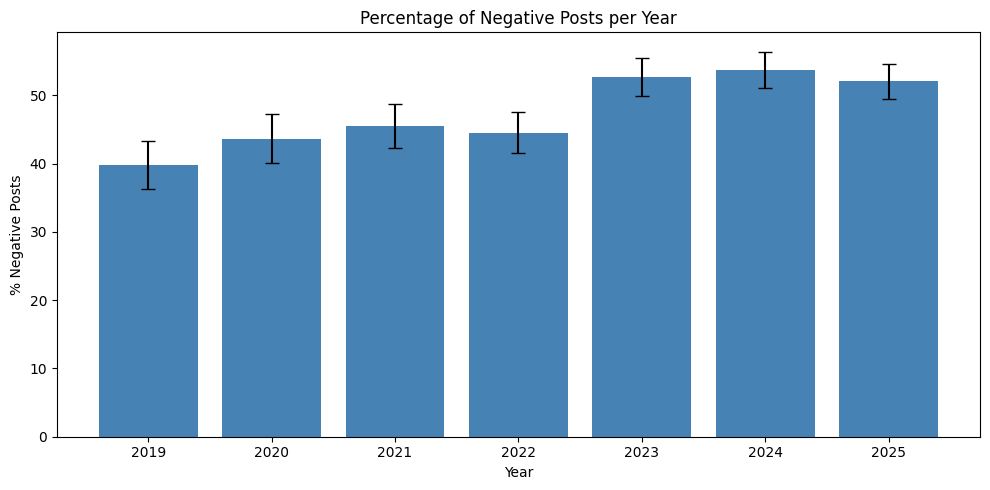

In [ ]:
def neg_pct_and_ci(group, confidence=0.95):
    binary = (group["sentiment"] == "neg").astype(int)
    n = len(binary)
    mean = binary.mean()
    se = stats.sem(binary)
    ci = se * stats.t.ppf((1 + confidence) / 2, n - 1)
    return mean * 100, ci * 100

yearly_stats = reddit_data.groupby("year").apply(neg_pct_and_ci).apply(pd.Series)
yearly_stats.columns = ["neg_pct", "ci"]

fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(yearly_stats.index, yearly_stats["neg_pct"], yerr=yearly_stats["ci"],
       capsize=5, color="steelblue", error_kw={"ecolor": "black", "linewidth": 1.5})
ax.set_xlabel("Year")
ax.set_ylabel("% Negative Posts")
ax.set_title("Percentage of Negative Posts per Year")
ax.set_xticks(yearly_stats.index)
plt.tight_layout()
# plt.savefig("neg_posts_per_year.png")
plt.show()

/var/folders/mj/jdg6nf_91m30_bh08_9683mr0000gn/T/ipykernel_67211/3746841861.py:2: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  monthly = reddit_data.groupby("date").apply(


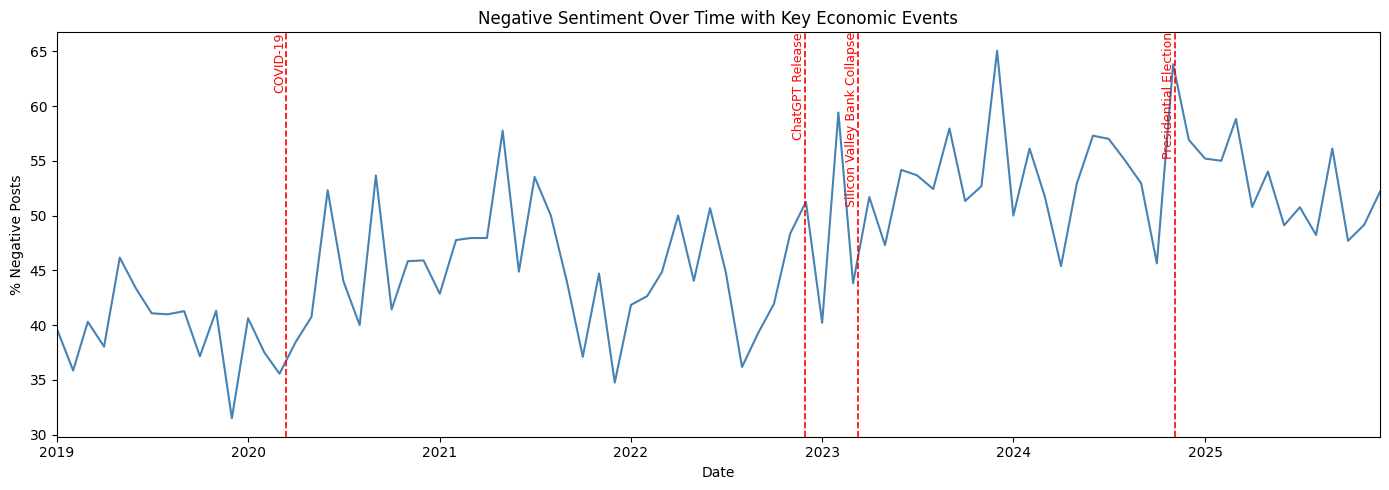

In [23]:
reddit_data["date"] = pd.to_datetime(reddit_data[["year", "month"]].assign(day=1))
monthly = reddit_data.groupby("date").apply(
    lambda x: (x["sentiment"] == "neg").mean() * 100
).reset_index()
monthly.columns = ["date", "neg_pct"]

events = {
    "COVID-19": "2020-03-13",
    "ChatGPT Release": "2022-11-30",
    "Silicon Valley Bank Collapse": "2023-03-10",
    "Presidential Election": "2024-11-05"
}

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(monthly["date"], monthly["neg_pct"], color="steelblue", linewidth=1.5)

for label, date in events.items():
    ax.axvline(pd.Timestamp(date), color="red", linestyle="--", linewidth=1.2)
    ax.text(pd.Timestamp(date), ax.get_ylim()[1], label, rotation=90,
            va="top", ha="right", fontsize=9, color="red")

ax.set_xlabel("Date")
ax.set_ylabel("% Negative Posts")
ax.set_title("Negative Sentiment Over Time with Key Economic Events")
ax.xaxis.set_major_locator(mdates.YearLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
ax.set_xlim(monthly["date"].min(), monthly["date"].max())
plt.tight_layout()
plt.show()

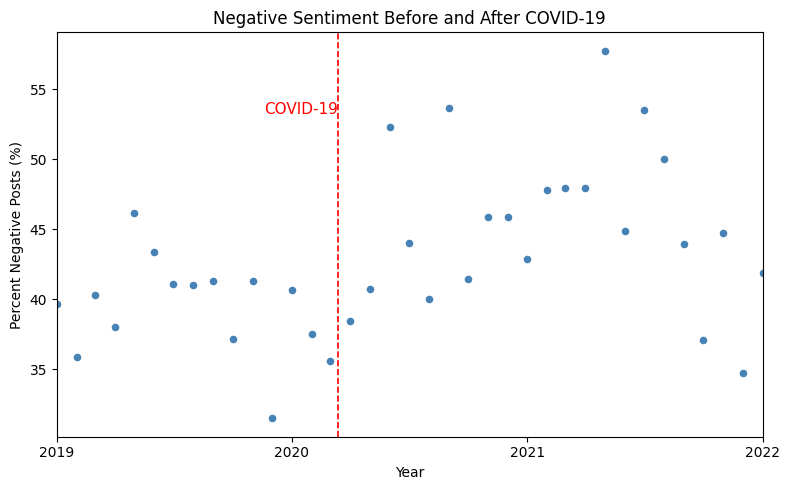

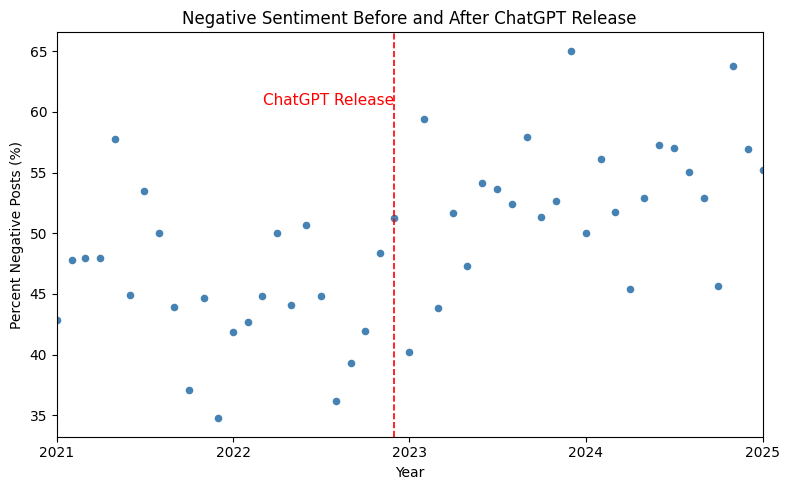

In [ ]:
events = [
    ("COVID-19", "2020-03-13", "2019-01-01", "2022-01-01"),
    ("ChatGPT Release", "2022-11-30", "2021-01-01", "2025-01-01"),
]

for label, event_date, start, end in events:
    fig, ax = plt.subplots(figsize=(8, 5))
    mask = (monthly["date"] >= start) & (monthly["date"] <= end)
    data = monthly[mask]
    ax.scatter(data["date"], data["neg_pct"], color="steelblue", s=20)
    ax.axvline(pd.Timestamp(event_date), color="red", linestyle="--", linewidth=1.2)
    ax.text(pd.Timestamp(event_date), ax.get_ylim()[1] - 5, label, rotation=0, va="top", ha="right", fontsize=11, color="red")
    ax.set_xlabel("Year")
    ax.set_ylabel("Percent Negative Posts (%)")
    ax.set_title(f"Negative Sentiment Before and After {label}")
    ax.xaxis.set_major_locator(mdates.YearLocator())
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
    ax.set_xlim(pd.Timestamp(start), pd.Timestamp(end))
    plt.tight_layout()
    # plt.savefig(f"{label.strip().replace(' ', '_')}.png")
    plt.show()